In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../ecg_dataset.csv")
df.head()

,filename,mean,std,max,min,peak_count,heart_rate,energy,zero_crossings,hrv,rr_mean,skewness,kurtosis,age,sex,label
0,JS00001.mat,19.511733,83.211649,415.083333,-200.833333,19,114.0,3.652443e+07,159,24.929345,256.166667,0.958782,1.488216,85,1,1
1,JS00002.mat,4.972017,74.998264,574.250000,-231.916667,11,66.0,2.824730e+07,216,195.853415,423.200000,4.290909,26.917034,59,0,1
2,JS00004.mat,-8.400400,84.366609,492.416667,-313.250000,17,102.0,3.594146e+07,35,116.207233,281.437500,2.905775,12.950834,66,1,1
3,JS00005.mat,-4.695617,229.715727,1017.500000,-724.333333,27,162.0,2.639568e+08,247,2.631174,185.000000,0.961059,6.763139,73,0,1
4,JS00006.mat,-2.071617,90.179287,541.083333,-99.166667,9,54.0,4.068298e+07,52,12.046135,529.875000,3.227648,12.561682,46,0,1


In [4]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45152 entries, 0 to 45151
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   filename        45152 non-null  object 
 1   mean            45152 non-null  float64
 2   std             45152 non-null  float64
 3   max             45152 non-null  float64
 4   min             45152 non-null  float64
 5   peak_count      45152 non-null  int64  
 6   heart_rate      45152 non-null  float64
 7   energy          45152 non-null  float64
 8   zero_crossings  45152 non-null  int64  
 9   hrv             45152 non-null  float64
 10  rr_mean         45152 non-null  float64
 11  skewness        45152 non-null  float64
 12  kurtosis        45152 non-null  float64
 13  age             45152 non-null  int64  
 14  sex             45152 non-null  int64  
 15  label           45152 non-null  int64  
dtypes: float64(10), int64(5), object(1)
memory usage: 5.5+ MB


In [5]:
df.isnull().sum()

filename          0
mean              0
std               0
max               0
min               0
peak_count        0
heart_rate        0
energy            0
zero_crossings    0
hrv               0
rr_mean           0
skewness          0
kurtosis          0
age               0
sex               0
label             0
dtype: int64

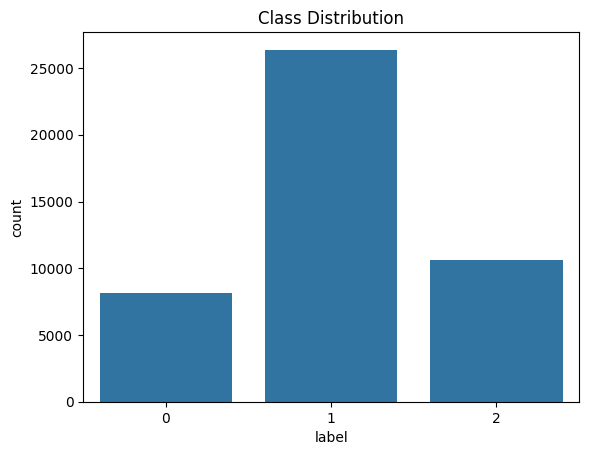

In [6]:
sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.show()

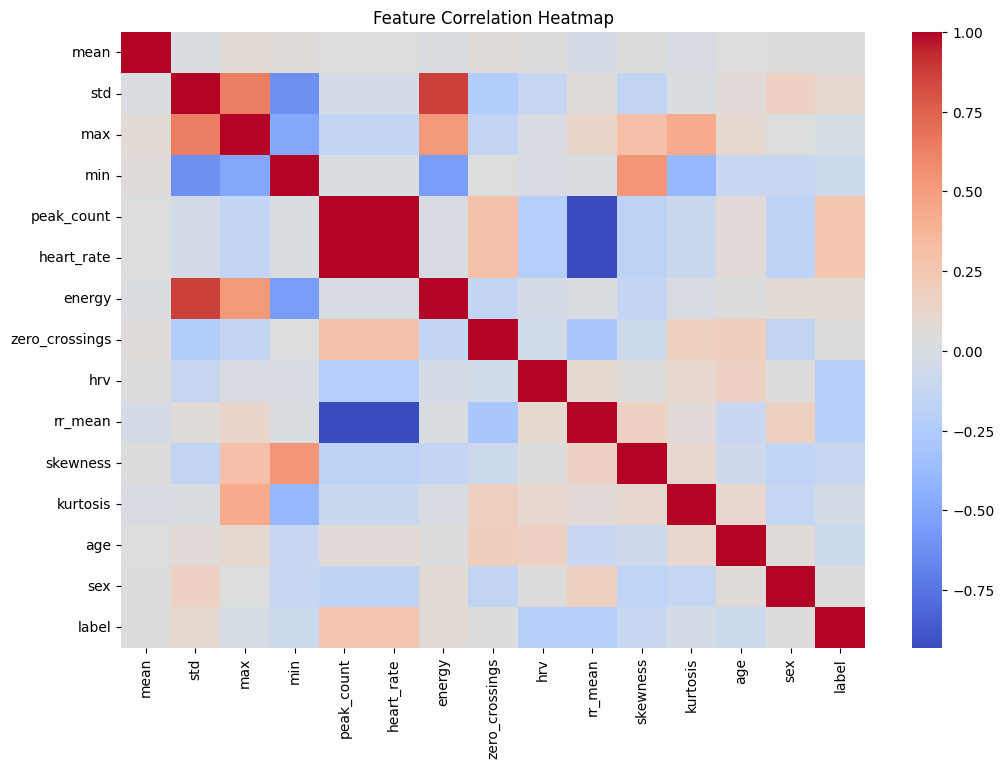

In [8]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

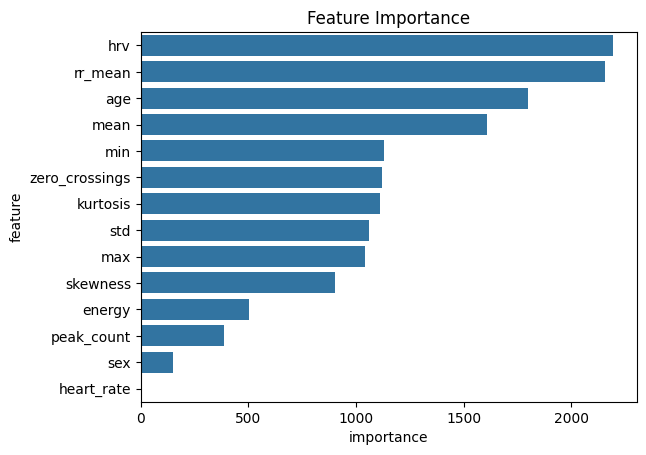

In [10]:
import joblib

model = joblib.load("../model.pkl")

importances = model.feature_importances_
features = df.drop(columns=["label", "filename"]).columns

imp_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

sns.barplot(x="importance", y="feature", data=imp_df)
plt.title("Feature Importance")
plt.show()

In [11]:
df.describe()

,mean,std,max,min,peak_count,heart_rate,energy,zero_crossings,hrv,rr_mean,skewness,kurtosis,age,sex,label
count,45152.000000,45152.000000,45152.000000,45152.000000,45152.000000,45152.000000,4.515200e+04,45152.000000,45152.000000,45152.000000,45152.000000,45152.000000,45152.000000,45152.000000,45152.000000
mean,1.559212,118.062535,616.245954,-448.477496,16.719835,100.319011,8.695331e+07,156.618799,77.776039,323.678199,1.300730,11.523175,58.136339,0.563253,1.056033
std,16.649840,56.323426,338.009093,396.636330,4.260145,25.560868,1.454926e+08,111.497127,57.123323,94.137467,2.048067,13.318546,19.784342,0.496970,0.642493
min,-441.685317,5.438897,23.250000,-12654.250000,1.000000,6.000000,1.479347e+05,0.000000,0.000000,0.000000,-16.462344,-1.489715,-1.000000,-1.000000,0.000000
25%,-1.068000,85.846470,421.979167,-531.083333,14.000000,84.000000,3.718238e+07,79.000000,25.809431,260.444444,0.024711,5.207982,48.000000,0.000000,1.000000
50%,2.411033,109.111359,573.833333,-379.750000,17.000000,102.000000,6.014576e+07,122.000000,78.514012,292.575368,1.516860,9.095801,61.000000,1.000000,1.000000
75%,5.220567,137.066774,748.166667,-259.416667,19.000000,114.000000,9.489994e+07,199.000000,119.429575,370.000000,2.736268,14.653871,72.000000,1.000000,1.000000
max,452.078533,1119.195687,11880.416667,85.916667,33.000000,198.000000,6.272594e+09,1432.000000,1507.555195,1411.333333,16.015882,525.949636,89.000000,1.000000,2.000000


In [12]:
sample = df.iloc[0]
sample

filename              JS00001.mat
mean                    19.511733
std                     83.211649
max                    415.083333
min                   -200.833333
peak_count                     19
heart_rate                  114.0
energy            36524430.972222
zero_crossings                159
hrv                     24.929345
rr_mean                256.166667
skewness                 0.958782
kurtosis                 1.488216
age                            85
sex                             1
label                           1
Name: 0, dtype: object